# **Projet de Machine Learning**
#**Prédiction du rendement agricole à l’aide de modèles de régression en Machine Learning**
##*Novembre, 2025*

# **Étape 1** — **Cerner le problème et rechercher une vision d’ensemble**:



**Objectif** **général** **du projet :**

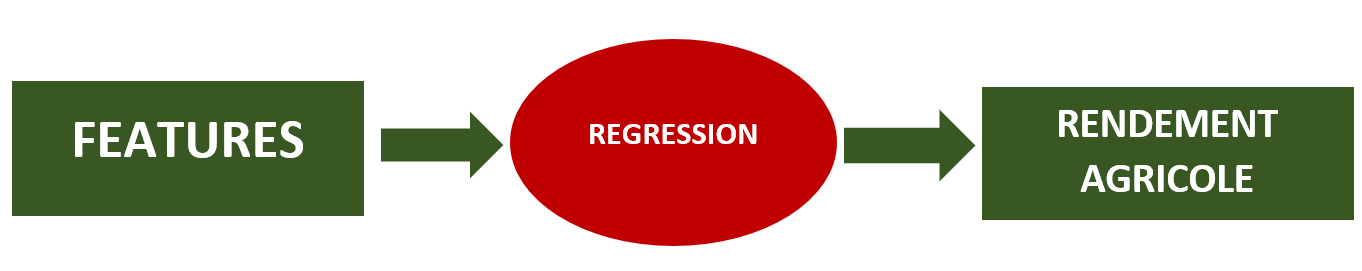

**Objectif professionnel:**


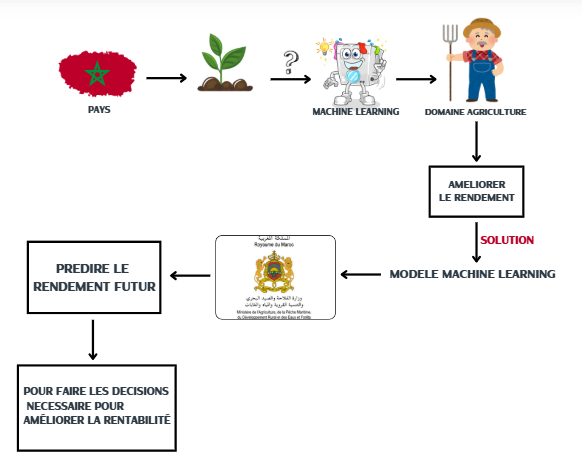

**Source du dataset :**

Dans ce projet, nous utilisons un dataset public provenant de Kaggle, intitulé :


*   Agricultural Crop Yield in Indian States Dataset


*   [lien kaggle](https://www.kaggle.com/datasets/akshatgupta7/crop-yield-in-indian-states-dataset
)






Ce jeu de données contient des informations agricoles détaillées sur plusieurs cultures cultivées dans différents États de l’Inde, couvrant une période allant de 1997 à 2020.

La taille du dataset est d’environ 1,62 Mo, ce qui le rend facilement manipulable tout en étant suffisamment riche pour l’apprentissage automatique.

Le dataset fournit des variables clés pour la prédiction du rendement agricole, notamment :


*   le type de culture,
*   l’année et la saison de culture,
*   la région (État),
*   la surface cultivée,
*   la production totale,
*   les précipitations annuelles,
*   l’utilisation d’engrais et de pesticides,
*   le rendement (Yield), qui constitue la variable cible.

Bien que ces données proviennent de l’Inde et non du Maroc, le modèle entraîné peut être réutilisé dans le contexte marocain, à condition de disposer de données locales présentant des caractéristiques similaires.

**La mesure de performance choisie s’accorde-t‑elle à notre objectif
professionnel ?**

Notre objectif professionnel est d’aider les agriculteurs à prédire le rendement afin d’améliorer la rentabilité et la prise de décision agricole.

Nous pouvons assurer que notre modele fait des predictions correcte  par plusieurs métriques d’évaluation, puisque toutes permettent d’évaluer la capacité de notre modèle à prédire le rendement en mesurant l’erreur qu’il a commise. Cependant, chaque métrique est plus robuste dans certains cas que dans d’autres.

Puisque il est difficile de contrôler la présence des valeurs extrêmes (outliers) et nous ne savons pas s’il y en a peu ou beaucoup. C’est pourquoi nous avons choisi d’utiliser à la fois le RMSE et le MAE :

*   **RMSE**(Root Mean Squared Error) = pénalise davantage les grandes erreurs, ce qui est important pour éviter des décisions agricoles coûteuses.
*   **MAE** (Mean Absolute Error) = donne une mesure stable et interprétable de l’erreur moyenne,
*   **R²**(coefficient de détermination) = lorsqu’il est élevé, il indique que le modèle capte bien l’influence des facteurs agricoles (pluie, engrais, pesticides) sur le rendement, ce qui renforce la confiance dans son utilisation opérationnelle.


**Quelle est la performance minimale permettant d’atteindre notre objectif professionnel ?**

Pour que le modèle soit utile en pratique :


*   **R² ≥ 0.70**

→ le modèle explique au moins 70 % de la variabilité du rendement

*   **MAE< 15–20 % du rendement moyen**

*   **RMSE < 20–25 % du rendement moyen**

→ suffisamment précis pour guider les décisions agricoles


# **Étape 2 — Obtenir les données**

**2.1 Télécharger le jeu de données :**

In [ ]:
import pandas as pd

rendements = pd.read_csv(
    "data/crop_yield.csv",
    sep=",",           # séparateur virgule
    engine="python",   # moteur plus robuste
    skipinitialspace=True  # ignore les espaces après la virgule
)

**2.2 vérifier la taille :**

In [ ]:
rendements.shape

(19689, 10)

# **Étape 3 — EXPLORER LES DONNÉES**

L’exploration initiale est réalisée sur l’ensemble du dataset afin de comprendre la structure des données (types de variables, distributions, valeurs manquantes).

En revanche, toutes les analyses impliquant la variable cible, telles que l’étude des corrélations ou la sélection de variables, sont effectuées exclusivement sur le jeu d’entraînement afin d’éviter toute fuite de données (data leakage).

In [ ]:
rendement = rendements.copy()

In [ ]:
rendement.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [ ]:
rendement.tail()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
11284,Rice,2009,Summer,Uttar Pradesh,24695.0,61514,585.8,3847974.90,4198.15,2.130000
11964,Maize,2010,Rabi,West Bengal,17229.0,84356,1096.0,2861909.19,4134.96,3.234545
5390,Onion,2017,Rabi,Tamil Nadu,16518.0,153558,970.9,2600593.92,6276.84,9.684074
860,Castor seed,2001,Kharif,Karnataka,21799.0,16137,1002.9,2226331.87,5667.74,0.704000
15795,Sesamum,2017,Kharif,Punjab,2700.0,900,497.5,425088.00,1026.00,0.292222


In [ ]:
summary = pd.DataFrame({
    "Type": rendement.dtypes,
    "Exemple valeur": rendement.iloc[0]
})
summary

,Type,Exemple valeur
Crop,object,Groundnut
Crop_Year,int64,2011
Season,object,Kharif
State,object,Goa
Area,float64,357.0
Production,int64,1022
Annual_Rainfall,float64,3340.395455
Fertilizer,float64,59804.64
Pesticide,float64,117.81
Yield,float64,2.86


In [ ]:
rendement.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15751 entries, 19466 to 15795
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             15751 non-null  object 
 1   Crop_Year        15751 non-null  int64  
 2   Season           15751 non-null  object 
 3   State            15751 non-null  object 
 4   Area             15751 non-null  float64
 5   Production       15751 non-null  int64  
 6   Annual_Rainfall  15751 non-null  float64
 7   Fertilizer       15751 non-null  float64
 8   Pesticide        15751 non-null  float64
 9   Yield            15751 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.3+ MB


**Nombre de valeurs manquantes:**

In [ ]:
rendement.isna().sum()

,0
Crop,0
Crop_Year,0
Season,0
State,0
Area,0
Production,0
Annual_Rainfall,0
Fertilizer,0
Pesticide,0
Yield,0


**Pourcentage de valeurs manquantes:**

In [ ]:
(rendement.isna().mean() * 100).sort_values(ascending=False)

,0
Crop,0.0
Crop_Year,0.0
Season,0.0
State,0.0
Area,0.0
Production,0.0
Annual_Rainfall,0.0
Fertilizer,0.0
Pesticide,0.0
Yield,0.0


In [ ]:
# Statistiques de base
rendement.describe()


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


## **Suppression des variables à risque de fuite d’information**

D’après la visualisation du DataFrame, nous avons remarqué qu’il existe une variable Production qui doit être supprimée, car le modèle peut se baser uniquement sur elle pour déduire le rendement. En réalité, le rendement (Yield) est calculé à partir de la production, ce qui constitue une fuite d’information.

In [ ]:
features_to_drop = [
    "Production"
]

rendement = rendement.drop(columns=features_to_drop, errors="ignore")


**Distribution de la variable cible :**

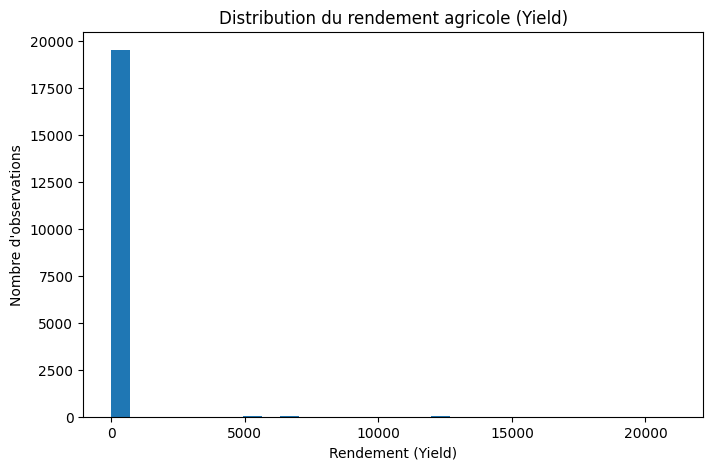

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(rendement["Yield"], bins=30)
plt.xlabel("Rendement (Yield)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution du rendement agricole (Yield)")
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables quantitatives
quantitative_vars = [
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

# Variables qualitatives
qualitative_vars = [
    "Crop",
    "Season",
    "State",
    "Crop_Year"
]


**Distribution des variables quantitatifs :**

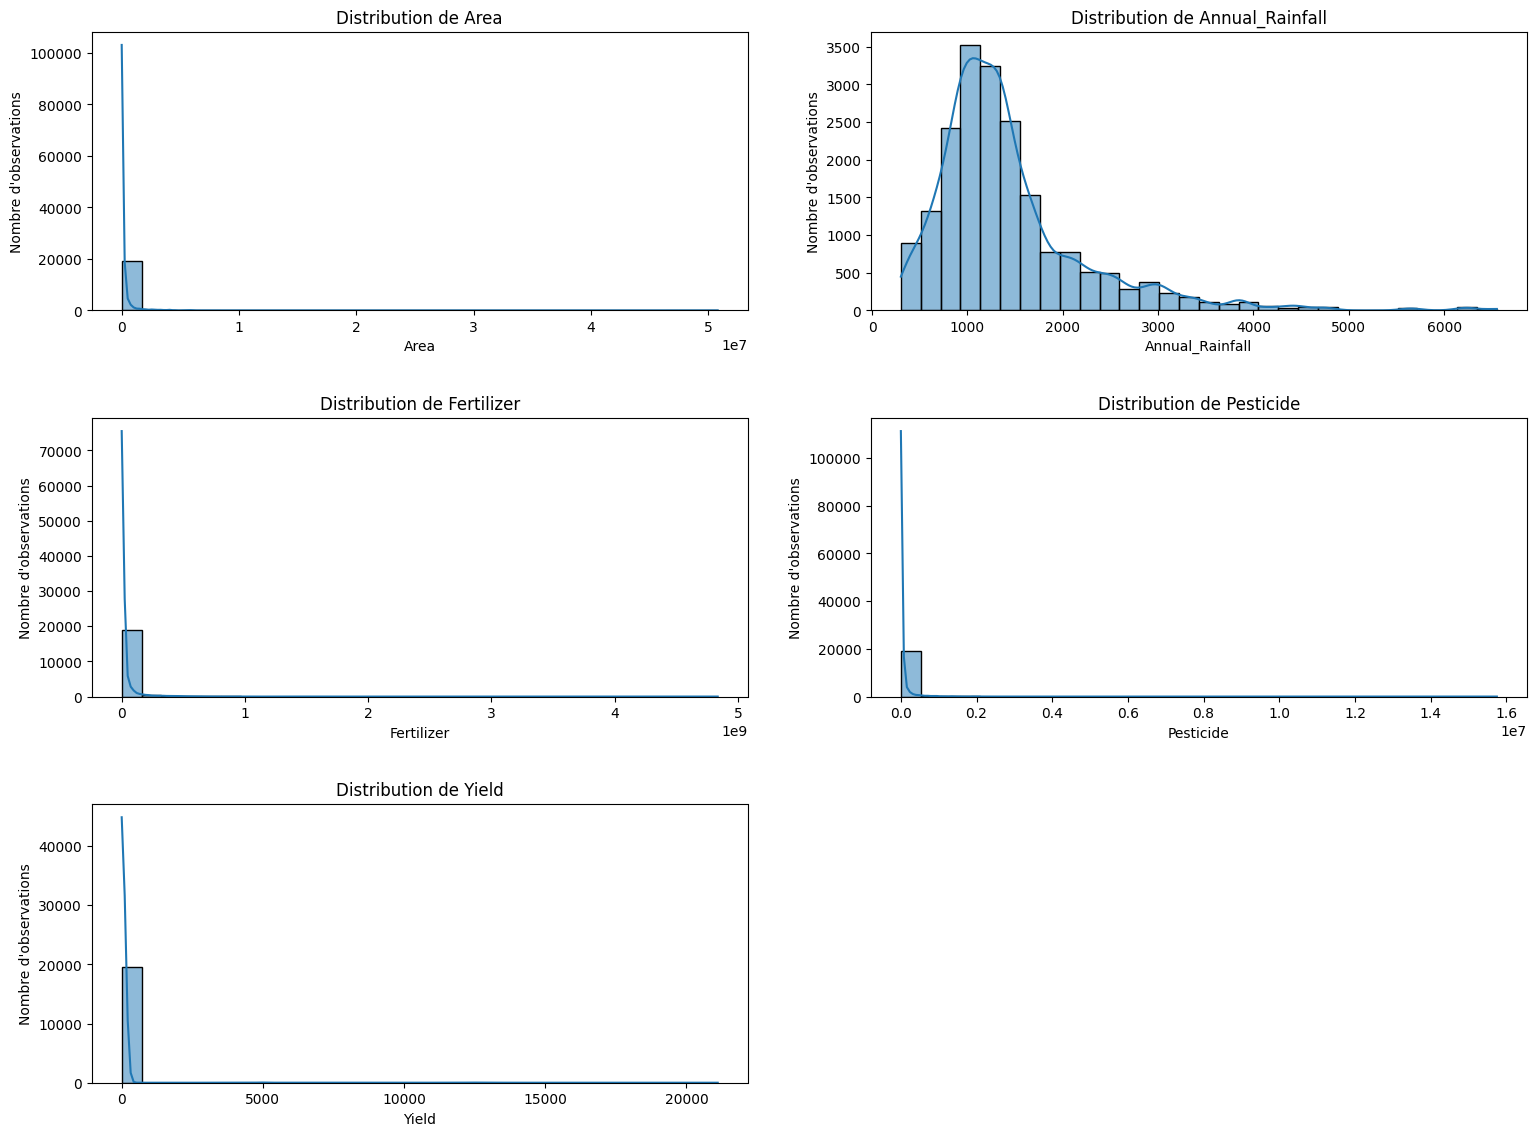

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 2
n_rows = math.ceil(len(quantitative_vars) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(quantitative_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(rendement[col], bins=30, kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre d'observations")

plt.tight_layout(pad=3.0)  #  espace entre graphiques
plt.show()


**Distribution des variables catégorielles :**

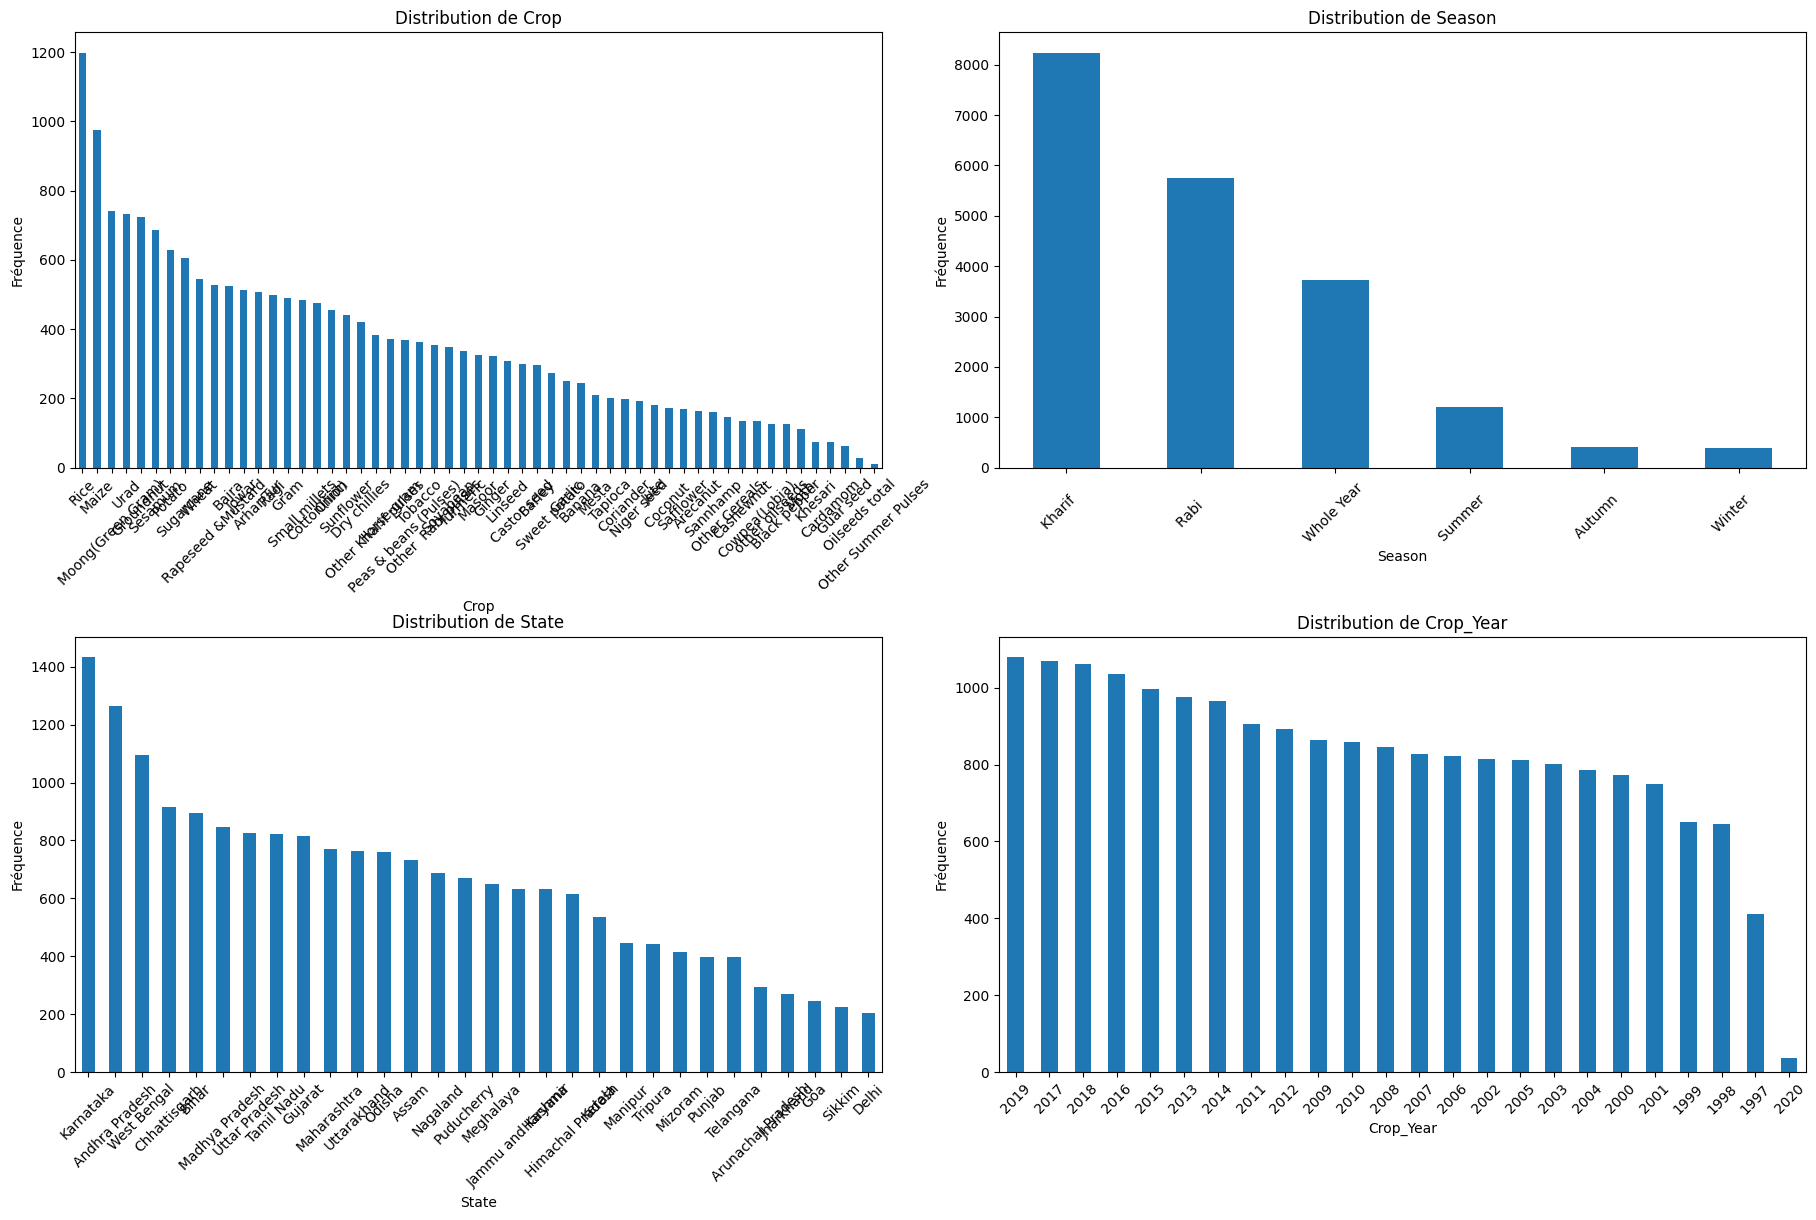

In [ ]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(qualitative_vars, 1):
    plt.subplot(2, 2, i)
    rendement[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.xticks(rotation=45)

plt.tight_layout(pad=0)
plt.show()


**Jeu de test :**

In [ ]:
from sklearn.model_selection import train_test_split

# Séparation train / test (80% / 20%)
train_set, test_set = train_test_split(
    rendement,
    test_size=0.2,
    random_state=42
)

print("Taille du jeu d'entraînement :", train_set.shape)
print("Taille du jeu de test :", test_set.shape)


Taille du jeu d'entraînement : (15751, 9)
Taille du jeu de test : (3938, 9)


**Séparation features / cible :**

In [ ]:

# Séparer le train set en X_train et y_train
X_train = train_set.drop("Yield", axis=1)
y_train = train_set["Yield"]

# Séparer le test set en X_test et y_test
X_test = test_set.drop("Yield", axis=1)
y_test = test_set["Yield"]

# Vérification des dimensions
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)


X_train : (15751, 8)
y_train : (15751,)
X_test  : (3938, 8)
y_test  : (3938,)


**Matrice de corrélation (Pearson):**

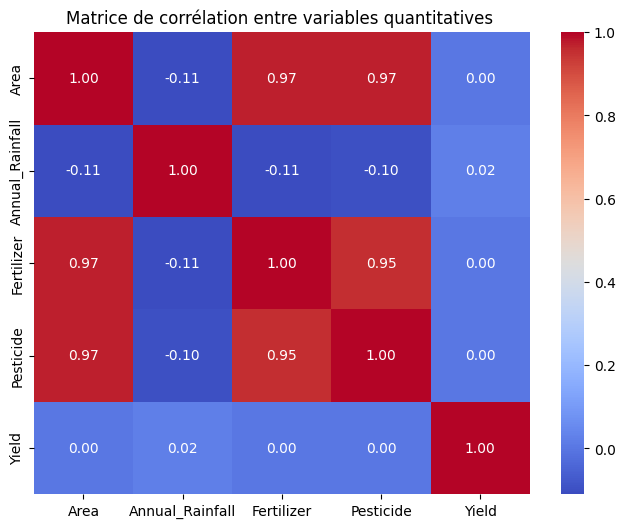

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = rendement[quantitative_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matrice de corrélation entre variables quantitatives ")
plt.show()


**Scatter plots (relation visuelle avec Yield):**

 Pour voir si la relation est linéaire ou non.

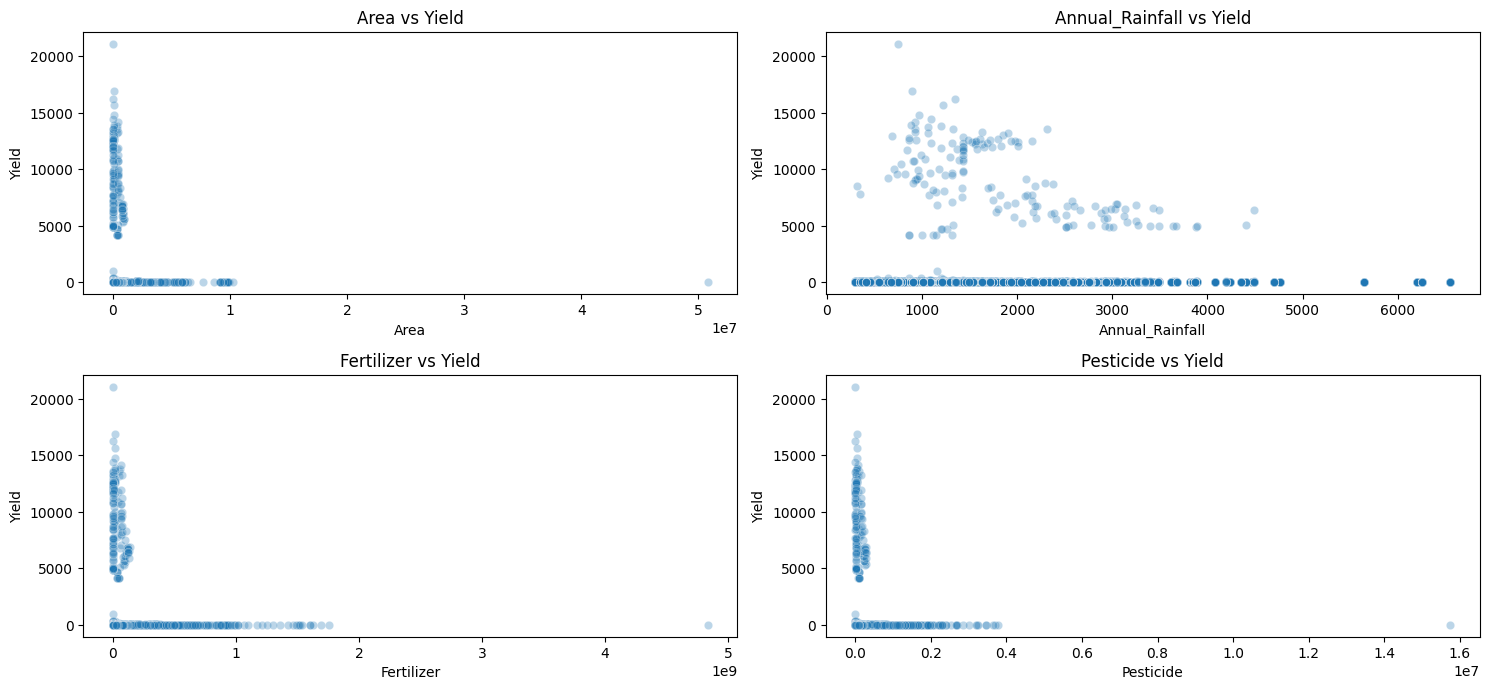

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(quantitative_vars[:-1], 1):  # sans Yield
    plt.subplot(3, 2, i)
    sns.scatterplot(x=rendement[col], y=rendement["Yield"], alpha=0.3)
    plt.title(f"{col} vs Yield")
    plt.xlabel(col)
    plt.ylabel("Yield")

plt.tight_layout()
plt.show()


Interprétation des courbes LOWESS

Les courbes LOWESS obtenues sont presque plates pour l’ensemble des variables analysées. Cela signifie qu’il n’existe pas de relation claire et globale entre chaque variable prise séparément et le rendement agricole. Ce résultat s’explique par la forte dispersion des données, la présence de nombreuses valeurs de rendement faibles, et le fait que le rendement dépend de plusieurs facteurs en même temps. Ainsi, l’absence de tendance visible ne signifie pas l’absence de relation, mais indique que la relation est complexe et multivariée.

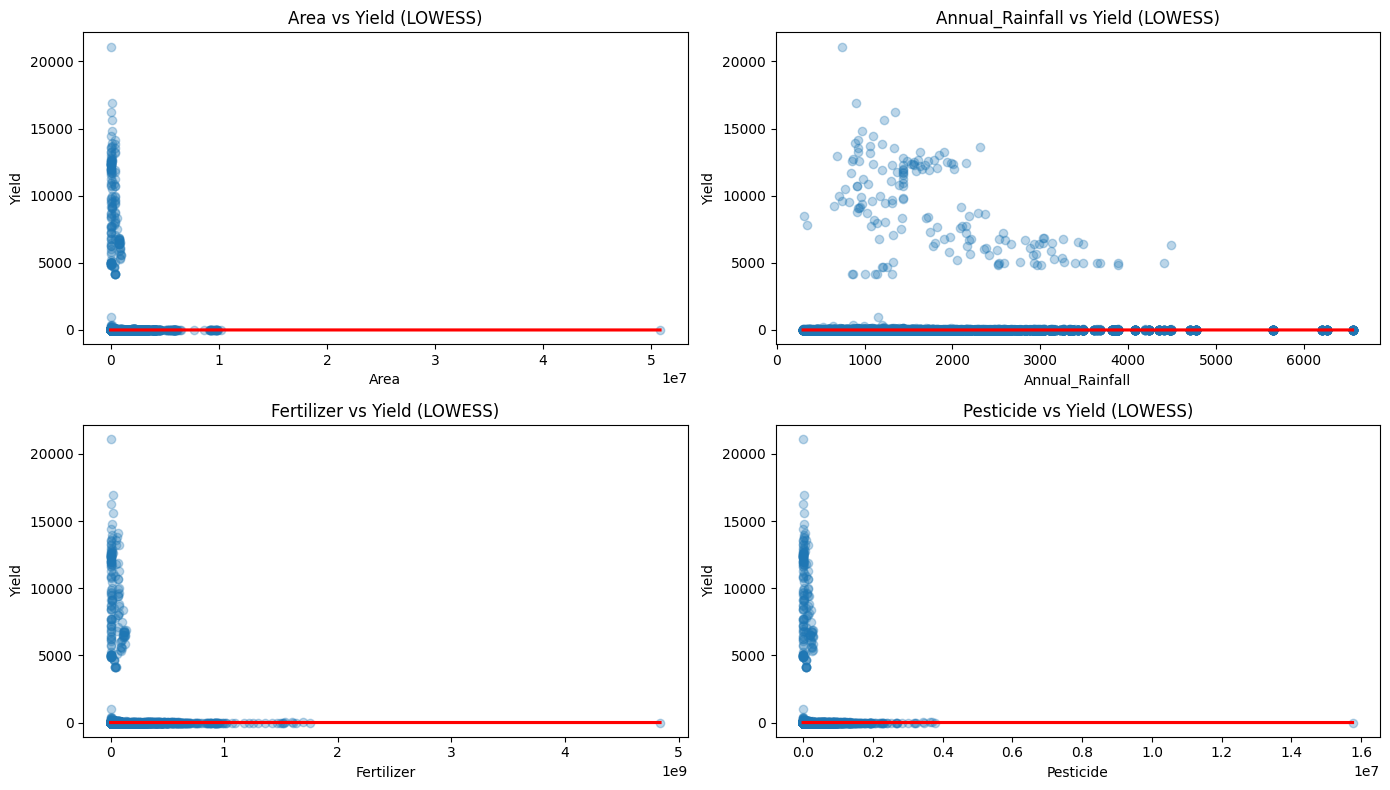

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

features = [
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]

target = "Yield"

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

plt.figure(figsize=(14, 4 * n_rows))

for i, feature in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.regplot(
        x=rendement[feature],
        y=rendement[target],
        lowess=True,
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )

    plt.title(f"{feature} vs {target} (LOWESS)")
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()


# **Synthèse des décisions issues de l’exploration:**

À la suite de l’exploration des données, plusieurs décisions de prétraitement ont été prises afin d’assurer la qualité des données, la stabilité des modèles et une bonne capacité de généralisation.

 **1. Gestion des valeurs manquantes :**

Bien que l’exploration initiale n’ait pas révélé de valeurs manquantes explicites, la présence de faux manquants (par exemple `na`, `Unknown`, chaînes vides) a été anticipée.  
Toutes ces modalités sont uniformisées en valeurs **NaN**, puis traitées par des méthodes d’imputation adaptées, les outils de Scikit-Learn ne reconnaissant que ce format.

 **2. Imputation des valeurs manquantes :**

- **Variables catégorielles** : imputation par la modalité la plus fréquente, afin de préserver la structure dominante des données.
- **Variables quantitatives** : imputation par la médiane, plus robuste que la moyenne en présence de distributions asymétriques et de valeurs extrêmes.

**3. Traitement des variables quantitatives :**

L’analyse exploratoire a mis en évidence des distributions asymétriques, la présence d’outliers et des échelles très différentes entre les variables quantitatives.
- Une **transformation logarithmique** est appliquée afin de réduire l’influence des valeurs extrêmes, stabiliser la variance et rapprocher les distributions d’une forme plus normale.
- Un **feature scaling** est ensuite appliqué pour rendre les variables comparables, éviter qu’une variable domine la fonction de coût uniquement par son échelle, et améliorer la stabilité numérique et la convergence des algorithmes de régression.

 **4.Traitement des variables qualitatives :**

Les variables qualitatives sont encodées après imputation afin de convertir l’information textuelle en une représentation numérique exploitable par les modèles de régression.

 **5.Traitement de la variable cible (Yield) :**

La variable cible présente une forte asymétrie et une longue traîne à droite.
Une **transformation logarithmique** est appliquée afin de réduire l’impact des valeurs extrêmes, stabiliser la variance et améliorer la capacité de généralisation du modèle.

**Cas particulier : variable Crop_Year**

La variable *Crop_Year* représente une année calendaire et constitue une variable temporelle ordinale.
Aucune transformation de normalité n’est appliquée, car sa signification repose sur l’ordre chronologique et non sur la forme de sa distribution. Une transformation logarithmique n’apporterait pas d’information pertinente et pourrait nuire à l’interprétation du modèle.


## **Étape 4 — Préparation des données**

### **4.1. Gestion des valeurs manquantes**

### **- Uniformisation des valeurs manquantes :**


In [ ]:
import numpy as np

# Valeurs considérées comme manquantes
fake_missing = ["na", "NA", "unknown", "Unknown", ""]

# Remplacement par NaN
rendement.replace(fake_missing, np.nan, inplace=True)

# Vérification
rendement.isna().sum()


,0
Crop,0
Crop_Year,0
Season,0
State,0
Area,0
Annual_Rainfall,0
Fertilizer,0
Pesticide,0
Yield,0


* Observation :
  * il n’y a ni valeurs manquantes explicites ni faux manquants ("na", "Unknown", chaînes vides, etc.)
  * Même s’il n’y a rien à imputer, on garde quand même la logique d’imputation dans le Pipeline pour rendre le modèle robuste à de nouvelles données

### **- Séparation des variables (quantitatives / catégorielles) :**

In [ ]:
# Variables catégorielles
cat_features = ["Crop", "Season", "State"]

# Variables numériques
num_features = [
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Crop_Year"
]


### **- Imputation des variables catégorielles :**
   * Remplacer les valeurs manquantes par la modalité la plus fréquente.

In [ ]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
X_test[cat_features] = cat_imputer.transform(X_test[cat_features])

### **- Imputation des variables quantitatives :**

- Utiliser une méthode robuste aux outliers.

In [ ]:
num_imputer = SimpleImputer(strategy="median")

X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features] = num_imputer.transform(X_test[num_features])


### **4.2. Traitement des variables quantitatives :**

### **- Sélection des variables quantitatives à transformer :**
- On doit enlever : Crop_Year

In [ ]:
num_features_2 = [
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]


### **- Transformation logarithmique des variables quantitatives :**

In [ ]:
import numpy as np

X_train[num_features_2] = np.log1p(X_train[num_features_2])
X_test[num_features_2] = np.log1p(X_test[num_features_2])


### **- Transformation de la variable cible (Yield) :**

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


### **- Scaling des variables quantitatives :**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])


### **4.3. Traitement des variables qualitatives :**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

### **- Définir le pipeline d’encodage des features :**

In [ ]:
# Préprocesseur : One-Hot sur les catégorielles, le reste passe tel quel
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="passthrough"
)

### **- Appliquer l’encodage :**

In [ ]:
# Fit UNIQUEMENT sur le train
X_train_prepared = preprocessor.fit_transform(X_train)

# Transform sur le test
X_test_prepared = preprocessor.transform(X_test)

# Vérifier
print("X_train_prepared :", X_train_prepared.shape)
print("X_test_prepared  :", X_test_prepared.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

type(X_train_prepared)


X_train_prepared : (15751, 96)
X_test_prepared  : (3938, 96)
y_train : (15751,)
y_test  : (3938,)


scipy.sparse._csr.csr_matrix

##**Étape 5 — Entrainement, sélection et évaluation des modèles**

### **- Méthode d’évaluation commune :**

- Cross-validation sur le jeu d’entraînement

- Métriques :

    - RMSE

    - MAE

    - R²

- La transformation logarithmique de la cible est prise en compte

## **5.1. Entraînement et évaluation des modèles baselines :**
- Avant d’utiliser des modèles complexes ou ensemblistes , il est indispensable d’entraîner des modèles simples de référence (baselines).

- Cette étape permet de :

   * établir un point de comparaison (baseline de performance)

   * comprendre le niveau de complexité nécessaire pour le problème

   * détecter rapidement : un underfitting (modèle trop simple) ou un overfitting (modèle trop complexe)

   * vérifier que les données et le prétraitement sont corrects
- Les modèles baselines choisis sont :

   * Régression linéaire

   * KNN Regressor

   * Arbre de décision

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np

###**- Définition des métriques :**

In [ ]:
scoring = {
    "RMSE": make_scorer(
        lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
        greater_is_better=False
    ),
    "MAE": make_scorer(
        mean_absolute_error,
        greater_is_better=False
    ),
    "R2": "r2"
}


- Remarque importante
    * Scikit-Learn maximise toujours les scores →
les erreurs (RMSE, MAE) sont donc négatives
    * on prendra leur valeur absolue lors de l’interprétation.

### **- Modèle 1 — Régression linéaire :**
      Modèle le plus simple possible

      Sert de référence minimale

      Suppose une relation linéaire entre les variables et le rendement

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

cv_results_lin = cross_validate(
    lin_reg,
    X_train_prepared,
    y_train_log,
    cv=5,
    scoring=scoring
)

# Moyennes des scores
rmse_lin = -cv_results_lin["test_RMSE"].mean()
mae_lin = -cv_results_lin["test_MAE"].mean()
r2_lin = cv_results_lin["test_R2"].mean()

print("Régression linéaire")
print(f"RMSE : {rmse_lin:.3f}")
print(f"MAE  : {mae_lin:.3f}")
print(f"R²   : {r2_lin:.3f}")


Régression linéaire
RMSE : 0.429
MAE  : 0.264
R²   : 0.857


### **- Modèle 2 — KNN Regressor :**

      Modèle non paramétrique

      Capture des relations locales non linéaires

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

cv_results_knn = cross_validate(
    knn_reg,
    X_train_prepared,
    y_train_log,
    cv=5,
    scoring=scoring
)

rmse_knn = -cv_results_knn["test_RMSE"].mean()
mae_knn = -cv_results_knn["test_MAE"].mean()
r2_knn = cv_results_knn["test_R2"].mean()

print("KNN Regressor")
print(f"RMSE : {rmse_knn:.3f}")
print(f"MAE  : {mae_knn:.3f}")
print(f"R²   : {r2_knn:.3f}")


KNN Regressor
RMSE : 0.284
MAE  : 0.129
R²   : 0.937


### **- Modèle 3 — Arbre de décision :**

       Modèle non linéaire

       Capte des interactions complexes

       Très interprétable

       Souvent sujet à l’overfitting → parfait pour diagnostic

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(
    random_state=42,
    max_depth=None
)

cv_results_tree = cross_validate(
    tree_reg,
    X_train_prepared,
    y_train_log,
    cv=5,
    scoring=scoring
)

rmse_tree = -cv_results_tree["test_RMSE"].mean()
mae_tree = -cv_results_tree["test_MAE"].mean()
r2_tree = cv_results_tree["test_R2"].mean()

print("Arbre de décision")
print(f"RMSE : {rmse_tree:.3f}")
print(f"MAE  : {mae_tree:.3f}")
print(f"R²   : {r2_tree:.3f}")


Arbre de décision
RMSE : 0.310
MAE  : 0.138
R²   : 0.925


### **Conclusion de l’étape “Modèles baselines”**

- Les modèles baselines montrent clairement que :

     - le problème de prédiction du rendement agricole est fortement non linéaire

     - les modèles capables de capturer des interactions et des relations complexes surpassent largement la régression linéaire

     - les performances atteintes dépassent déjà les seuils professionnels définis (R² ≥ 0.70)

- Ces observations justifient naturellement l’utilisation de modèles plus robustes et plus puissants.

## **5.2. Modèle ensembliste homogène : Random Forest Regressor :**



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

### **- Définition du modèle :**
- On commence volontairement avec des hyperparamètres raisonnables, afin de comparer équitablement avec les modèles baselines.
- Explication des paramètres :
    - n_estimators=200 : nombre d’arbres dans la forêt

     - random_state=42 : reproductibilité des résultats

     - n_jobs=-1 : utilisation de tous les cœurs du processeur

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

### **- Validation croisée :**

In [ ]:
cv_results_rf = cross_validate(
    rf_reg,
    X_train_prepared,
    y_train_log,
    cv=5,
    scoring=scoring
)
rmse_rf = -cv_results_rf["test_RMSE"].mean()
mae_rf = -cv_results_rf["test_MAE"].mean()
r2_rf = cv_results_rf["test_R2"].mean()

print("Random Forest Regressor")
print(f"RMSE : {rmse_rf:.3f}")
print(f"MAE  : {mae_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")


Random Forest Regressor
RMSE : 0.236
MAE  : 0.113
R²   : 0.957


### **- Conclusion de l’étape Random Forest :**

- Le Random Forest Regressor permet de :

   - réduire le sur-apprentissage observé avec les arbres de décision

   - obtenir un modèle plus stable et plus robuste

   - confirmer que les relations entre les variables agricoles et le rendement sont complexes et non linéaires

- Ces résultats justifient l’exploration de méthodes ensemblistes encore plus avancées.

## **5.3. Modèle ensembliste hétérogène : Voting Regressor :**



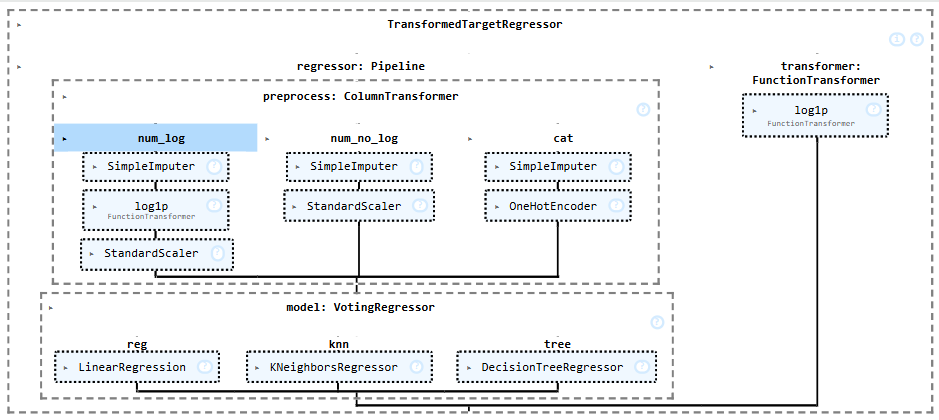

In [ ]:
from sklearn.ensemble import VotingRegressor


### **- Construction du Voting Regressor 1 :**
         KNN
         Régression linéaire
         Arbre de décision

In [ ]:
voting_reg_1 = VotingRegressor(
    estimators=[
        ("lin_reg", lin_reg),
        ("knn", knn_reg),
        ("tree", tree_reg)
    ],
    n_jobs=-1
)

### **- Validation croisée :**

In [ ]:
cv_results_voting = cross_validate(
    voting_reg_1,
    X_train_prepared,
    y_train_log,
    cv=5,
    scoring=scoring
)
rmse_voting = -cv_results_voting["test_RMSE"].mean()
mae_voting = -cv_results_voting["test_MAE"].mean()
r2_voting = cv_results_voting["test_R2"].mean()

print("Voting Regressor 1")
print(f"RMSE : {rmse_voting:.3f}")
print(f"MAE  : {mae_voting:.3f}")
print(f"R²   : {r2_voting:.3f}")


Voting Regressor
RMSE : 0.265
MAE  : 0.147
R²   : 0.945


### **- Construction du Voting Regressor 2 :**
           KNN
           Régression linéaire
           Random Forest

In [ ]:
voting_reg_2 = VotingRegressor(
    estimators=[
        ("lin_reg", lin_reg),
        ("knn", knn_reg),
        ("RF", rf_reg)
    ],
    n_jobs=-1
)

### **- Validation croisée :**

In [ ]:
cv_results_voting = cross_validate(
    voting_reg_2,
    X_train_prepared,
    y_train_log,
    cv=5,
    scoring=scoring
)
rmse_voting = -cv_results_voting["test_RMSE"].mean()
mae_voting = -cv_results_voting["test_MAE"].mean()
r2_voting = cv_results_voting["test_R2"].mean()

print("Voting Regressor 2")
print(f"RMSE : {rmse_voting:.3f}")
print(f"MAE  : {mae_voting:.3f}")
print(f"R²   : {r2_voting:.3f}")


Voting Regressor
RMSE : 0.260
MAE  : 0.146
R²   : 0.948


### **Étape 6 — Sélection et évaluation du modèle finale**



### **- Récapitulatif des résultats obtenus :**









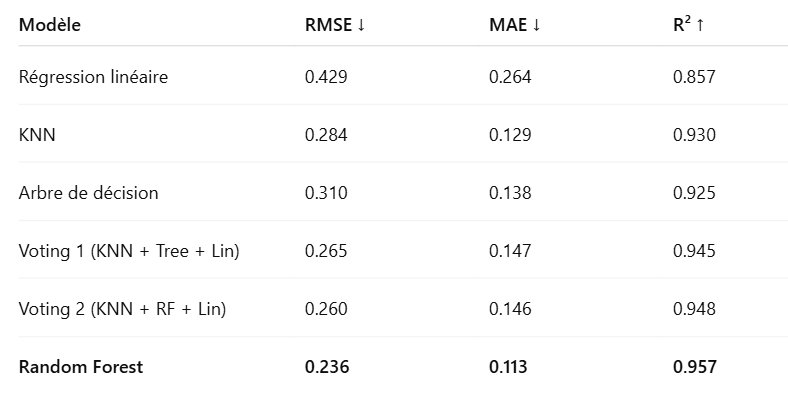

### **- Entraînement final sur tout le train set :**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_prepared, y_train_log)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

### **- Prédictions sur le jeu de test :**
 - Les prédictions sont en échelle logarithmique

In [ ]:
y_test_pred_log = rf_final.predict(X_test_prepared)

### **- Retour à l’échelle originale du rendement :**

In [ ]:
import numpy as np

y_test_pred = np.expm1(y_test_pred_log)
y_test_true = np.expm1(y_test_log)

###**- Calcul des métriques finales :**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae_test = mean_absolute_error(y_test_true, y_test_pred)
r2_test = r2_score(y_test_true, y_test_pred)

print("Évaluation finale — Jeu de test")
print(f"RMSE : {rmse_test:.3f}")
print(f"MAE  : {mae_test:.3f}")
print(f"R²   : {r2_test:.3f}")


Évaluation finale — Jeu de test
RMSE : 120.654
MAE  : 8.649
R²   : 0.982


## **Conclusion finale et interprétation des résultats :**


---

L’évaluation finale sur un jeu de test indépendant montre une excellente capacité de généralisation du modèle (R² = 0.982), ainsi qu’une erreur moyenne faible (MAE = 8.649), ce qui rend le modèle exploitable dans un contexte opérationnel.

Le RMSE plus élevé observé ne traduit pas une mauvaise performance globale, mais résulte de quelques erreurs très importantes sur des observations extrêmes.

Cette interprétation est corroborée par la combinaison des métriques (MAE faible, R² élevé, RMSE sensible aux grandes erreurs) et par la nature même du domaine agricole, où des conditions atypiques et difficilement prévisibles peuvent survenir.

Ainsi, le modèle final retenu est à la fois performant, robuste et cohérent avec les objectifs professionnels du projet : aider à la prédiction du rendement afin d’améliorer la prise de décision agricole.

Les résultats obtenus confirment que le modèle fournit des prédictions fiables dans la majorité des situations, tout en mettant en évidence les limites inhérentes aux cas extrêmes, qui constituent une piste naturelle pour des analyses futures (étude des erreurs, enrichissement des données ou intégration de nouvelles variables explicatives).